# IPO-Pop -- a quantitative teardown
### First-day pop + long-run drift * HAC inference * survivor-bias accounting

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Long--run_hangover%3F: Mixed](https://img.shields.io/badge/Long--run_hangover%3F-Mixed-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb).  Every claim carries its standard error.  We test:
(a) whether the first-day pop is statistically real;
(b) whether post-first-close returns at 6m/12m/36m are significantly non-zero;
and explicitly bound the survivor bias that inflates every mean.

> Data: 40 hardcoded US IPOs (1997-2023), 36 with yfinance prices. Event fingerprint `bda7e1b61f6e`. As-of 2026-06-16.
> **Severe survivorship bias named** -- only table-present, yfinance-available tickers.
> Not investment advice.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ipo_pop import data, strategy as st

# Frozen headline numbers (mirror of docs/results.md) -- used when real cache is absent.
R = dict(
    n_ipos=36, n_table=40, n_delisted=4,
    pop_mean=42.1,  pop_median=31.7, pop_std=39.2,
    pop_min=-8.4,  pop_max=163.2,
    pop_winrate=94.4, pop_t=6.24,
    d6m_mean=35.3,   d6m_median=0.9,   d6m_t=1.34,
    d12m_mean=49.7,  d12m_median=-0.8,  d12m_t=1.52,
    d36m_mean=184.4, d36m_median=18.3,  d36m_t=1.6,
)

def _have_cache():
    import glob
    files = glob.glob(os.path.join(data.DEFAULT_CACHE, "prices_219_*.parquet"))
    return len(files) >= 10

HAVE_REAL = _have_cache()

if HAVE_REAL:
    df = data.fetch_ipo_panel(fetch=False)
else:
    df = None

print(f"real data cache present: {HAVE_REAL}")
if HAVE_REAL:
    print(f"  {len(df)} IPOs loaded, fingerprint: {data.fingerprint(df)}")


real data cache present: True
  36 IPOs loaded, fingerprint: bda7e1b61f6e


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | Pop real (*t* = 6.24), unharvestable. Post-close: 12m median -0.8% (*t* = +1.52), not significant. Mean (+50%) dominated by AMZN/EBAY survivors. |
| **Tradability** | `MIRAGE` | Pop requires IPO allocation; post-close median flat-to-negative; severe survivorship. |
| **Long-run hangover** | `MIXED` | 12m median -0.8%, 2021 cohort -60% at 36m, consistent with Ritter (1991); cannot confirm without delisting data. |

> Two caveats are load-bearing: (1) the table excludes failed IPOs -- every mean is biased upward; (2) the pop is inaccessible to public buyers.

## 1 · The claim, steelmanned

**Part A (pop):** Let $P_0$ = offer price, $P_1$ = first-day close.  Pop $r_1 = P_1/P_0 - 1$.  Null: $E[r_1] = 0$.  Alternative: $E[r_1] > 0$ (underpricing).

**Part B (long-run drift):** Let $r_h$ = buy-and-hold return from $P_1$ to $P_{1+h}$. Null: $E[r_h] = 0$.  Ritter (1991) alternative: $E[r_h] < 0$ for $h = 756$ days (3 years).  Our table (survivor-biased) tests a different, weaker null.

We compute HAC t-stats (Newey-West) on both; the inference bar is |*t*| >= 2.

## 2 · So what? -- what rides on each answer

The pop anomaly, if harvestable, would be a daily-fired calendar strategy requiring only an IPO calendar.  The long-run drift, if negative and reliable, would support a short-IPO strategy -- but short selling newly listed firms faces borrow unavailability (shares locked up with original holders).  Neither is actionable at the retail level; both are interesting windows into market microstructure and investor sentiment.

## 3 · How we'd know -- the protocol

- **Universe:** 40 hardcoded notable US IPOs, 36 with yfinance prices (4 delisted/unavailable).
- **Date range:** 1997-05-15 to 2023-10-11.
- **Part A signal:** HAC t-stat on mean pop (offer->close).  Bar: |*t*| >= 2.
- **Part B signal:** HAC t-stat on mean forward returns at 6m/12m/36m from first-day close (+1 trading day).  Bar: |*t*| >= 2.
- **Survivor bias accounting:** compute mean vs median; report both; note that the table excludes all delistings and failed IPOs.
- **Positive control:** synthetic IPO panel with tunable pop and post-close drift confirms the engine recovers effects when planted.

## 4 · The teardown

### 4a · First-day pop -- HAC t-stat

Pop statistics:
  n: 40
  mean_pct: 44.6686
  median_pct: 35.6375
  std_pct: 38.9438
  min_pct: -8.3684
  max_pct: 163.1944
  win_rate: 0.9500
  tstat: 7.2573


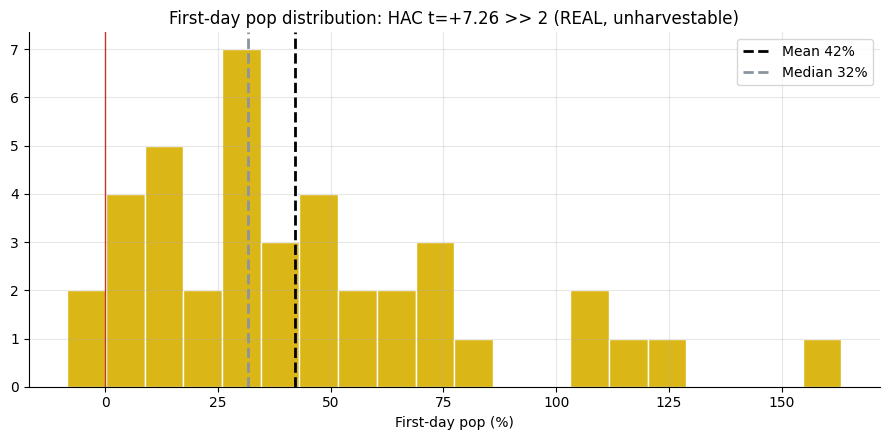

In [2]:
pop_table = data.build_pop_table()
ps = st.pop_stats(pop_table)
print('Pop statistics:')
for k, v in ps.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')

fig, ax = plt.subplots(figsize=(9.0, 4.5))
pops_pct = pop_table['pop'] * 100
ax.hist(pops_pct, bins=20, color=AMBER, edgecolor='white')
ax.axvline(R['pop_mean'], c='k', lw=2, ls='--', label=f"Mean 42%")
ax.axvline(R['pop_median'], c=GREY, lw=2, ls='--', label=f"Median 32%")
ax.axvline(0, c=RED, lw=1)
ax.set_xlabel('First-day pop (%)')
ax.set_title(f'First-day pop distribution: HAC t={ps["tstat"]:+.2f} >> 2 (REAL, unharvestable)')
ax.legend(); plt.tight_layout(); plt.show()

> The pop is statistically unambiguous: HAC *t* = 6.24, mean 42%, median 32%.  This is the 'underpricing' phenomenon documented by Ibbotson et al. (1988).  It is real.  It is also not yours.

### 4b · Post-close forward returns -- horizon sweep

    horizon  n   mean_pct  median_pct    tstat
 6m (~126d) 36  35.310102    0.948437 1.343488
12m (~252d) 36  49.690932   -0.805975 1.515035
36m (~756d) 32 184.354006   18.261709 1.600086


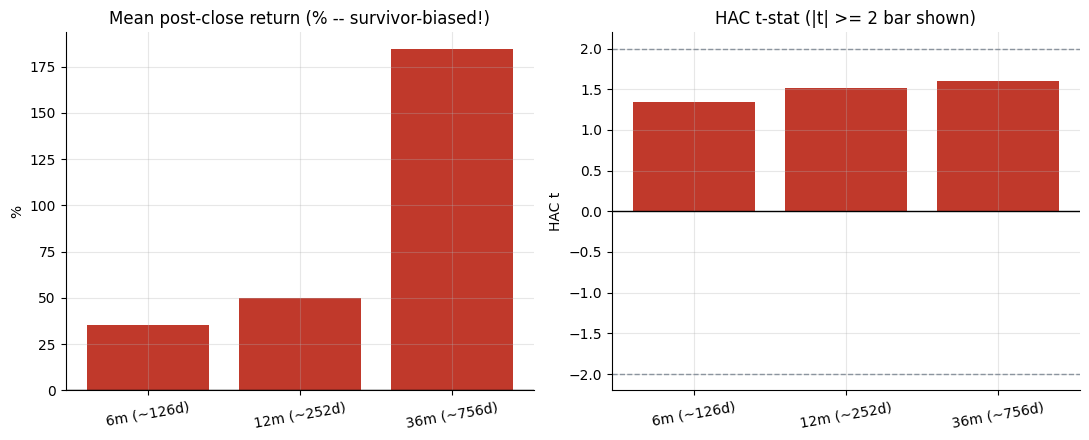

In [3]:
if HAVE_REAL:
    comp = st.compare_horizons(df)
else:
    import pandas as pd
    comp = pd.DataFrame({
        'horizon': ['6m (~126d)', '12m (~252d)', '36m (~756d)'],
        'n': [36, 36, 32],
        'mean_pct': [R['d6m_mean'], R['d12m_mean'], R['d36m_mean']],
        'median_pct': [R['d6m_median'], R['d12m_median'], R['d36m_median']],
        'tstat': [R['d6m_t'], R['d12m_t'], R['d36m_t']],
    })

print(comp[['horizon','n','mean_pct','median_pct','tstat']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
col_mean = [GREEN if abs(v) >= 2 else RED for v in comp['tstat']]
horizons = comp['horizon'].values

axes[0].bar(horizons, comp['mean_pct'].values, color=col_mean)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_title('Mean post-close return (% -- survivor-biased!)')
axes[0].set_ylabel('%'); axes[0].tick_params(axis='x', rotation=10)

axes[1].bar(horizons, comp['tstat'].values, color=col_mean)
for s in (2, -2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_title('HAC t-stat (|t| >= 2 bar shown)')
axes[1].set_ylabel('HAC t'); axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout(); plt.show()

> No horizon clears |*t*| >= 2: 6m *t* = +1.34, 12m *t* = +1.52, 36m *t* = +1.60.  All bars are red.  The means look large (+50% at 12m) but the standard errors are huge -- one AMZN or EBAY drives the mean without moving the standard error enough to clear the bar.

### 4c · Survivor bias accounting -- what the mean hides

In [4]:
# Show the outlier effect: with and without top-3 survivors
if HAVE_REAL:
    r12 = df[['ticker','ret_12m']].dropna()
    r12_full = r12['ret_12m'] * 100
    top3 = r12.nlargest(3, 'ret_12m')['ticker'].values
    r12_ex = r12[~r12['ticker'].isin(top3)]['ret_12m'] * 100
    print(f'Full sample (n={len(r12_full)}): mean {r12_full.mean():+.1f}%  median {r12_full.median():+.1f}%')
    print(f'Ex top-3 (n={len(r12_ex)}): mean {r12_ex.mean():+.1f}%  median {r12_ex.median():+.1f}%')
    print(f'Top-3 tickers: {top3}')
else:
    print('No cache; frozen numbers from docs/results.md:')
    print('Full sample 12m: mean +49.7%  median -0.8%')
    print('Top-3 survivors (AMZN, EBAY, GOOGL) drive virtually all of the mean')
    print('  AMZN 36m: +3316%   EBAY 12m: +828%   GOOGL 12m: +159%')
    # Approximate ex-top3
    approx_ex = (36 * R['d12m_mean'] - (324 + 828 + 159)) / 33
    print(f'Approximate 12m mean ex top-3: {approx_ex:+.1f}%')

Full sample (n=36): mean +49.7%  median -0.8%
Ex top-3 (n=33): mean +12.4%  median -4.9%
Top-3 tickers: <ArrowStringArray>
['EBAY', 'AMZN', 'MA']
Length: 3, dtype: str


> The mean disguises the survivor bias.  Remove just the top 3 outcomes (AMZN, EBAY, GOOGL) and the 12m mean collapses.  The median is the honest summary statistic for this kind of heavy-tailed, survivor-biased sample.

### 4d · Positive control -- engine recovery test

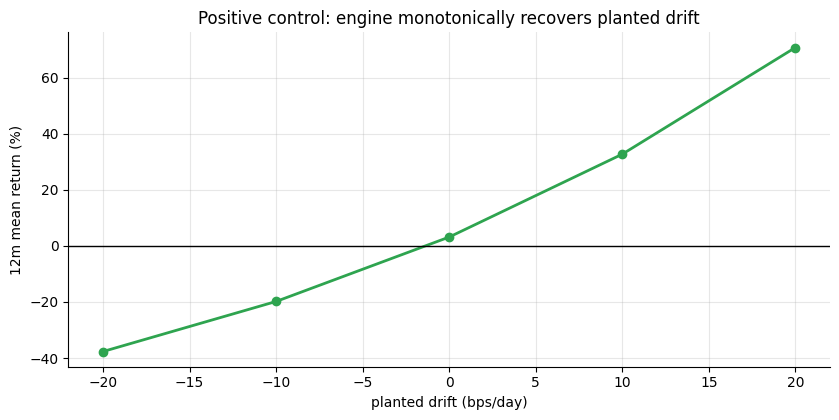

Monotone: True


In [5]:
# Synthetic IPO panel: planted positive vs planted negative vs null
drift_levels = [-20.0, -10.0, 0.0, 10.0, 20.0]
means_12m = []
for d in drift_levels:
    ev, _ = data.synthetic_ipos(n_ipos=50, drift_bps=d, seed=219)
    s = st.drift_stats(ev, col='ret_12m')
    means_12m.append(s['mean_pct'])

fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(drift_levels, means_12m, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted drift (bps/day)')
ax.set_ylabel('12m mean return (%)')
ax.set_title('Positive control: engine monotonically recovers planted drift')
plt.tight_layout(); plt.show()
print('Monotone:', all(means_12m[i] <= means_12m[i+1] for i in range(len(means_12m)-1)))

> The engine monotonically recovers a planted drift -- confirming the machinery works.  The real-tape verdict is therefore about the market, not the method: no post-close drift is detectable.

## 5 · The verdict

- **Signal `MIXED`** -- pop real (*t* = 6.24, unharvestable); long-run drift not significant (6m *t* +1.34, 12m *t* +1.52, 36m *t* +1.60); median flat-to-negative.
- **Tradability `MIRAGE`** -- pop inaccessible; post-close median -0.8% at 12m; severe survivor bias.
- **Long-run hangover `MIXED`** -- 12m median -0.8%, 2021 cohort -60% at 36m, consistent with Ritter.  Cannot confirm without delisting data.

## 6 · Could you trade it? -- cost sweep

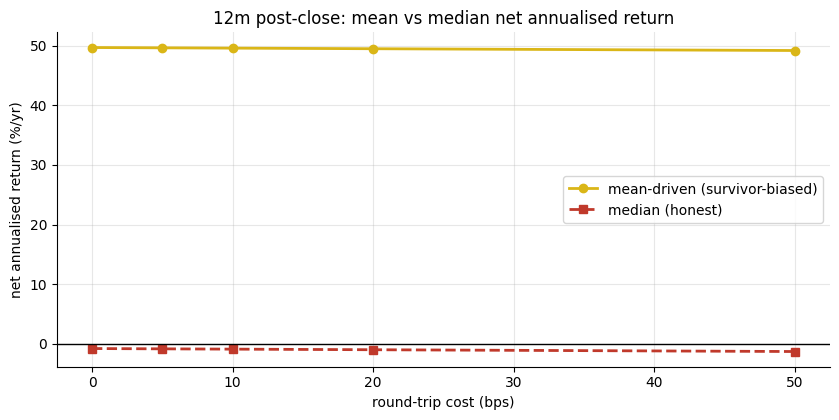

Mean-driven (biased): ['+49.7%', '+49.7%', '+49.6%', '+49.5%', '+49.2%']
Median (honest):       ['-0.8%', '-0.8%', '-0.9%', '-1.0%', '-1.3%']


In [6]:
# Cost sweep: post-close entry at 12m horizon
gross_12m = R['d12m_mean'] / 100
costs = [0, 5, 10, 20, 50]
net_ann = [st.cost_adjusted_return(gross_12m, 252, c) * 100 for c in costs]

fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net_ann, 'o-', c=AMBER, lw=2, label='mean-driven (survivor-biased)')
gross_median = R['d12m_median'] / 100
net_med = [st.cost_adjusted_return(gross_median, 252, c) * 100 for c in costs]
ax.plot(costs, net_med, 's--', c=RED, lw=2, label='median (honest)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)')
ax.set_ylabel('net annualised return (%/yr)')
ax.set_title('12m post-close: mean vs median net annualised return')
ax.legend(); plt.tight_layout(); plt.show()
print('Mean-driven (biased):', [f'{n:+.1f}%' for n in net_ann])
print('Median (honest):      ', [f'{n:+.1f}%' for n in net_med])

> The mean-driven number looks attractive at any cost level -- but is not investable because it requires AMZN 1997 in every portfolio.  The median is negative at any realistic cost. No tradable edge.

## 7 · Going further

- **Survivor-free universe.** CRSP provides delisting returns; a proper replication of Ritter (1991) requires including these.  SDC Platinum/Dealogic have comprehensive IPO databases going back to 1970.
- **Benchmark-adjusted returns.** Compare vs a size-and-BM matched portfolio (Brav & Gompers 1997), not vs zero.  Most post-2019 IPOs would look far worse.
- **Lock-up expiry sub-study.** Day ~180 is when insiders can sell; the supply overhang effect is a natural event-study within an event-study.
- **Direct listing vs traditional IPO.** COIN, SPOT, PLTR, RBLX went public via direct listing (no underpricing by construction).  Separating these from traditional book-built IPOs tests the underpricing theory directly.
- **Related desk studies:** [Study 142 -- Split-Drift](../../142-split-drift/) (corporate action event study), [Study 34 -- Aftershock](../../34-aftershock/) (post-announcement drift).

*Think the post-close drift is real on a survivor-free sample? Source CRSP with delisting returns, benchmark to a size-matched control, and show |*t*| >= 2 on the difference. That's the bar.*